### Implementation of GAIT

### Simple VAE

In [33]:
import os
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class H5Dataset(Dataset):
    def __init__(self, directory, transform=None, compute_stats=True, end_time=-1):
        """
        Args:
            directory (str): Path to the directory containing .h5 files.
            transform (callable, optional): Optional transform to be applied on a sample.
            compute_stats (bool): Whether to compute global min and max for normalization.
        """
        self.end_time = end_time
        self.directory = directory
        # List all .h5 files in the directory
        self.file_list = sorted(
            [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.h5')]
        )
        
        self.transform = transform
        self.global_min = None
        self.global_max = None

        if compute_stats:
            self.global_min, self.global_max = self._compute_global_min_max()
            print(f"Computed global min: {self.global_min}, global max: {self.global_max}")

    def _compute_global_min_max(self):
        """Compute the minimum and maximum values across all files in the dataset."""
        global_min = float("inf")
        global_max = -float("inf")
        for file_path in self.file_list:
            with h5py.File(file_path, 'r') as h5_file:
                density = h5_file['density'][:]
                vort = h5_file['omega'][:]
                phi = h5_file['phi'][:]
                # Stack the individual arrays into a single state array.
                state = np.stack((density, vort, phi), axis=0)
                current_min = state.min()
                current_max = state.max()
                if current_min < global_min:
                    global_min = current_min
                if current_max > global_max:
                    global_max = current_max
        return global_min, global_max

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        with h5py.File(file_path, 'r') as h5_file:
            density = h5_file['density'][:self.end_time]
            vort = h5_file['omega'][:self.end_time]
            phi = h5_file['phi'][:self.end_time]
            state = np.stack((density, vort, phi), axis=0)
        # Convert to torch tensor
        tensor_data = torch.tensor(state, dtype=torch.float32)
        # Apply global min-max normalization if stats are computed.
        if self.global_min is not None and self.global_max is not None:
            tensor_data = (tensor_data - self.global_min) / (self.global_max - self.global_min)
        if self.transform:
            tensor_data = self.transform(tensor_data)
        return tensor_data


In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Conv3DVAE(nn.Module):
    def __init__(
        self,
        in_channels=1,
        latent_dim=64,
        hidden_dims=(16, 32, 64),
        time_dim=8,
        x_dim=64,
        y_dim=64
    ):
        """
        Args:
            in_channels (int): Number of input channels.
            latent_dim   (int): Dimensionality of the latent space.
            hidden_dims (tuple): Sequence of channels for intermediate convolution layers.
            time_dim     (int): Temporal dimension of your input.
            x_dim        (int): Spatial x dimension of your input.
            y_dim        (int): Spatial y dimension of your input.
        """
        super(Conv3DVAE, self).__init__()

        # Save original input dimensions for later cropping in the decoder
        self.input_time_dim = time_dim
        self.input_x_dim = x_dim
        self.input_y_dim = y_dim

        # -------------------------
        #    ENCODER
        # -------------------------
        encoder_modules = []
        prev_channels = in_channels
        for h in hidden_dims:
            encoder_modules.append(
                nn.Sequential(
                    nn.Conv3d(
                        in_channels=prev_channels,
                        out_channels=h,
                        kernel_size=3,
                        stride=2,
                        padding=1
                    ),
                    nn.ReLU(inplace=True),
                )
            )
            prev_channels = h
        self.encoder_conv = nn.Sequential(*encoder_modules)

        # Use a dummy pass to calculate the output dimensions dynamically
        dummy_input = torch.zeros(1, in_channels, time_dim, x_dim, y_dim)
        dummy_out = self.encoder_conv(dummy_input)
        self.final_time_dim = dummy_out.shape[2]
        self.final_x_dim = dummy_out.shape[3]
        self.final_y_dim = dummy_out.shape[4]
        self.flattened_size = dummy_out.numel() // dummy_out.shape[0]
        print(f"Calculated flattened size: {self.flattened_size} "
              f"(channels: {prev_channels}, time: {self.final_time_dim}, "
              f"x: {self.final_x_dim}, y: {self.final_y_dim})")

        # Output heads for mean and log-variance of the latent vector
        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # -------------------------
        #    DECODER
        # -------------------------
        # Transform the latent vector back to a feature map
        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)

        # Build decoder using ConvTranspose3d in reverse order of hidden_dims
        decoder_modules = []
        rev_hidden_dims = list(hidden_dims)[::-1]
        for i in range(len(rev_hidden_dims) - 1):
            decoder_modules.append(
                nn.Sequential(
                    nn.ConvTranspose3d(
                        in_channels=rev_hidden_dims[i],
                        out_channels=rev_hidden_dims[i+1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1  # helps compensate for stride=2 downsampling
                    ),
                    nn.ReLU(inplace=True)
                )
            )
        self.decoder_conv = nn.Sequential(*decoder_modules)
        self.final_layer = nn.Sequential(
            nn.ConvTranspose3d(
                in_channels=rev_hidden_dims[-1],
                out_channels=in_channels,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid()  # final activation for reconstruction
        )

    def encode(self, x):
        """
        Encode the input into latent distribution parameters.
        """
        enc_out = self.encoder_conv(x)
        enc_out = torch.flatten(enc_out, start_dim=1)  # Flatten into (batch, flattened_size)
        mu = self.fc_mu(enc_out)
        logvar = self.fc_logvar(enc_out)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var) using
        standard normal noise.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """
        Decode the latent vector z back to the input dimensions.
        """
        x = self.decoder_input(z)
        # Reshape to the feature map dimensions coming out of encoder_conv
        x = x.view(
            -1,
            self.encoder_conv[-1][0].out_channels,
            self.final_time_dim,
            self.final_x_dim,
            self.final_y_dim
        )
        x = self.decoder_conv(x)
        x = self.final_layer(x)
        # Crop the output along the time dimension to match the original input
        if x.size(2) != self.input_time_dim:
            x = x[:, :, :self.input_time_dim, :, :]
        return x

    def forward(self, x):
        """
        Forward pass: encode input, reparameterize, and decode.
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

# Test the model with a dummy input for verification
if __name__ == "__main__":
    vae = Conv3DVAE(
        in_channels=3,
        latent_dim=64,
        hidden_dims=(16, 32, 64),
        time_dim=20,
        x_dim=64,
        y_dim=64
    )
    data = torch.randn(4, 3, 20, 64, 64)
    recon, mu, logvar = vae(data)
    print("Reconstruction shape:", recon.shape)
    print("Mean shape:", mu.shape)
    print("Logvar shape:", logvar.shape)


Calculated flattened size: 12288 (channels: 64, time: 3, x: 8, y: 8)
Reconstruction shape: torch.Size([4, 3, 20, 64, 64])
Mean shape: torch.Size([4, 64])
Logvar shape: torch.Size([4, 64])


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Hyper-parameters
learning_rate = 0.001
in_channels = 3  # Our data now has three channels: density, vort, phi
time_dim = 20
x_dim = 64
y_dim = 64
beta = 1.0    # KL divergence weight
batch_size = 4
num_epochs = 500

# Instantiate the model
model = Conv3DVAE(
    in_channels=in_channels,
    latent_dim=64,
    hidden_dims=(16, 32, 64),
    time_dim=time_dim,
    x_dim=x_dim,
    y_dim=y_dim
)

# Define the loss function
def loss_function(recon_x, x, mu, logvar):
    """
    Computes the VAE loss as the sum of reconstruction loss and the KL divergence.
    Args:
        recon_x: Reconstructed data from the decoder.
        x: Original input data.
        mu: Mean from the encoder.
        logvar: Log variance from the encoder.
    """
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss

# Create the dataset and dataloader
data_dir = '/Users/anthonypoole/data/local_dqfno/train/chunked'
dataset = H5Dataset(data_dir, end_time=20)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

# Choose device
device = 'cpu' if not torch.cuda.is_available() else 'cuda'
model = model.to(device)

# Setup optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# (Optional) Preview one batch to check normalization
for batch_idx, data in enumerate(dataloader):
    print(f"Batch {batch_idx}: {data.shape}")
    # Check the range of values: they should be between 0 and 1
    print("Data range:", data.min().item(), data.max().item())
    break

# Training loop
model.train()
for epoch in range(1, num_epochs + 1):
    train_loss = 0
    for batch_idx, data in enumerate(dataloader):
        data = data.to(device)  # Data is already normalized by the dataset
        optimizer.zero_grad()

        recon_data, mu, logvar = model(data)
        loss = loss_function(recon_data, data, mu, logvar)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Batch [{batch_idx}/{len(dataloader)}] "
                  f"Loss: {loss.item() / len(data):.4f}")

    average_loss = train_loss / len(dataset)
    print(f"====> Epoch: {epoch} Average loss: {average_loss:.4f}")

print("Training complete!")


Calculated flattened size: 12288 (channels: 64, time: 3, x: 8, y: 8)
Computed global min: -24.287668228149414, global max: 32.57217025756836
Batch 0: torch.Size([8, 3, 20, 64, 64])
Data range: 0.10490614920854568 0.9968769550323486
Epoch [1/500] Batch [0/20] Loss: 170259.4062
Epoch [1/500] Batch [10/20] Loss: 169074.4844
====> Epoch: 1 Average loss: 169270.7608
Epoch [2/500] Batch [0/20] Loss: 168381.1562
Epoch [2/500] Batch [10/20] Loss: 168079.6562
====> Epoch: 2 Average loss: 168134.2772
Epoch [3/500] Batch [0/20] Loss: 167951.5000
Epoch [3/500] Batch [10/20] Loss: 167918.1562
====> Epoch: 3 Average loss: 167899.0156
Epoch [4/500] Batch [0/20] Loss: 167844.4531
Epoch [4/500] Batch [10/20] Loss: 167809.2188
====> Epoch: 4 Average loss: 167826.1927
Epoch [5/500] Batch [0/20] Loss: 167816.3750
Epoch [5/500] Batch [10/20] Loss: 167806.0000
====> Epoch: 5 Average loss: 167799.4844
Epoch [6/500] Batch [0/20] Loss: 167798.4062
Epoch [6/500] Batch [10/20] Loss: 167787.6250
====> Epoch: 6 Av

In [43]:
test_data_dir = "/Users/anthonypoole/data/local_dqfno/test/chunked"
test_dataset = H5Dataset(test_data_dir)
test_dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

model.eval()
for data in test_dataloader:
    recon_data, mu, logvar = model(data)
    break

print(recon_data.shape)

Computed global min: -23.280073165893555, global max: 28.78862762451172
torch.Size([8, 3, 20, 64, 64])


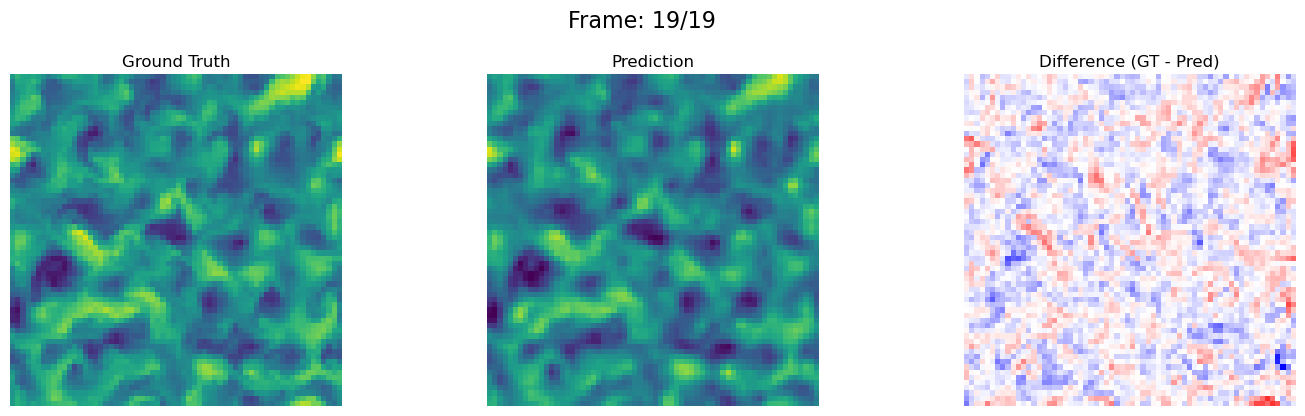

In [46]:
import h5py
from viz import animation, animation_comparison
from IPython.display import HTML

chan = 0
batch = 0
gt = data[batch,chan,:,:,:].detach().numpy()
pred = recon_data[batch,chan,:,:,:].detach().numpy()

ani = animation_comparison(gt, pred, show_difference=True)
HTML(ani.to_jshtml())  # Or use ani.to_html5_video() for better quality